# Deep_Learning

---

## Load Dataset

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [36]:
data = pd.read_csv("../../data/processed/integrated_data.csv")
data.head()

print(data.shape)

(100000, 22)


## Target

In [37]:
target = "is_churn"

print(data[target].value_counts())
print(data[target].value_counts(normalize=True))

is_churn
0    91049
1     8951
Name: count, dtype: int64
is_churn
0    0.91049
1    0.08951
Name: proportion, dtype: float64


In [38]:
data.isna().sum()

msno                          0
is_churn                      0
city                      11352
bd                        11352
gender                    60169
registered_via            11352
registration_init_time    11352
transaction_count             0
cancel_count                  0
total_payment                 0
last_auto_renew             138
last_is_cancel              138
last_plan_days              138
days_to_expire              138
cancel_on_last_date         138
activity_days                 0
total_secs                    0
total_num_100                 0
total_num_unq                 0
days_since_last_log       18281
has_transaction               0
has_log                       0
dtype: int64

## 평가 & 학습 데이터셋

In [39]:
# 8:2 분할
from sklearn.model_selection import train_test_split

train, valid = train_test_split(
    data,
    test_size=0.2,
    stratify=data[target],
    random_state=42
)

train = train.copy()
valid = valid.copy()

train.shape, valid.shape

((80000, 22), (20000, 22))

# EDA

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   msno                    100000 non-null  object 
 1   is_churn                100000 non-null  int64  
 2   city                    88648 non-null   float64
 3   bd                      88648 non-null   float64
 4   gender                  39831 non-null   object 
 5   registered_via          88648 non-null   float64
 6   registration_init_time  88648 non-null   float64
 7   transaction_count       100000 non-null  float64
 8   cancel_count            100000 non-null  float64
 9   total_payment           100000 non-null  float64
 10  last_auto_renew         99862 non-null   float64
 11  last_is_cancel          99862 non-null   float64
 12  last_plan_days          99862 non-null   float64
 13  days_to_expire          99862 non-null   float64
 14  cancel_on_last_date  

In [41]:
# 컬럼별 결측치 개수와 비율 확인
null_ratio = train.isnull().mean()

pd.DataFrame({"결측치 비율": null_ratio}).sort_values("결측치 비율", ascending=False)

,결측치 비율
gender,0.602125
days_since_last_log,0.183138
bd,0.113113
registered_via,0.113113
registration_init_time,0.113113
city,0.113113
days_to_expire,0.001350
last_auto_renew,0.001350
last_is_cancel,0.001350
last_plan_days,0.001350


In [42]:
train.describe()

,is_churn,city,bd,registered_via,registration_init_time,transaction_count,cancel_count,total_payment,last_auto_renew,last_is_cancel,last_plan_days,days_to_expire,cancel_on_last_date,activity_days,total_secs,total_num_100,total_num_unq,days_since_last_log,has_transaction,has_log
count,80000.000000,70951.000000,70951.000000,70951.000000,7.095100e+04,80000.000000,80000.000000,80000.000000,79892.000000,79892.000000,79892.000000,79892.000000,79892.000000,80000.000000,8.000000e+04,80000.000000,80000.000000,65349.000000,80000.000000,80000.000000
mean,0.089512,5.909008,13.503249,6.897140,2.013251e+07,15.773450,0.258663,2126.222500,0.881578,0.009701,35.181457,19.078631,0.017611,38.901863,3.077090e+05,1176.734175,1136.247537,4.373609,0.998650,0.816863
std,0.285484,6.428790,20.456424,1.934361,3.019727e+04,8.683796,0.564522,1258.497806,0.323110,0.098013,38.810508,26.764915,0.131535,31.051256,4.602965e+05,1888.534219,1519.355226,11.719927,0.036718,0.386782
min,0.000000,1.000000,-51.000000,3.000000,2.004033e+07,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-1156.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,7.000000,2.012021e+07,8.000000,0.000000,1043.000000,1.000000,0.000000,30.000000,9.000000,0.000000,6.000000,1.559313e+04,51.000000,70.000000,0.000000,1.000000,1.000000
50%,0.000000,1.000000,0.000000,7.000000,2.014052e+07,16.000000,0.000000,1881.000000,1.000000,0.000000,30.000000,18.000000,0.000000,38.000000,1.576764e+05,574.000000,635.000000,0.000000,1.000000,1.000000
75%,0.000000,13.000000,27.000000,9.000000,2.016012e+07,23.000000,0.000000,3278.000000,1.000000,0.000000,30.000000,26.000000,0.000000,68.000000,4.059961e+05,1515.000000,1592.000000,3.000000,1.000000,1.000000
max,1.000000,22.000000,1820.000000,13.000000,2.017023e+07,59.000000,11.000000,7450.000000,1.000000,1.000000,450.000000,892.000000,1.000000,90.000000,7.622046e+06,85874.000000,27088.000000,89.000000,1.000000,1.000000


In [43]:
# 두 집단의 최근 이용 활동 중앙값 비교
log_cols = ["activity_days", "total_secs", "total_num_100", "total_num_unq"]
display(train.groupby(target)[log_cols].median().T)

is_churn,0,1
activity_days,37.000,39.000
total_secs,155543.692,179283.702
total_num_100,566.000,661.000
total_num_unq,626.000,738.000


In [44]:
# 자동 갱신 여부별 고객 수와 이탈률 비교
summary = train.groupby("last_auto_renew", dropna=False)[target].agg(
    customers="size", churn_rate="mean"
)
display(summary)

,customers,churn_rate
last_auto_renew,,
0.0,9461,0.412113
1.0,70431,0.045307
NaN,108,0.657407


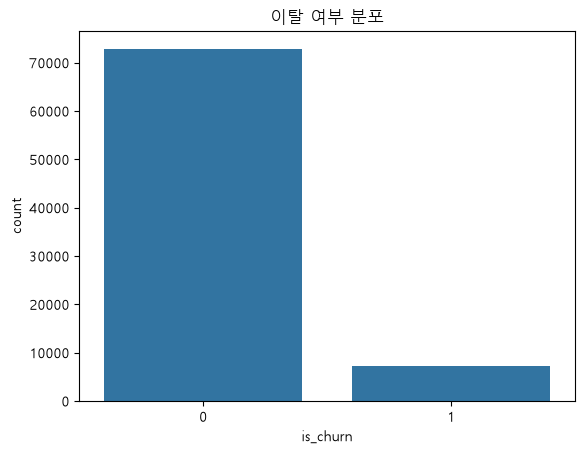

In [45]:
# 타깃 분포
sns.countplot(data=train, x="is_churn")
plt.title("이탈 여부 분포")
plt.show()

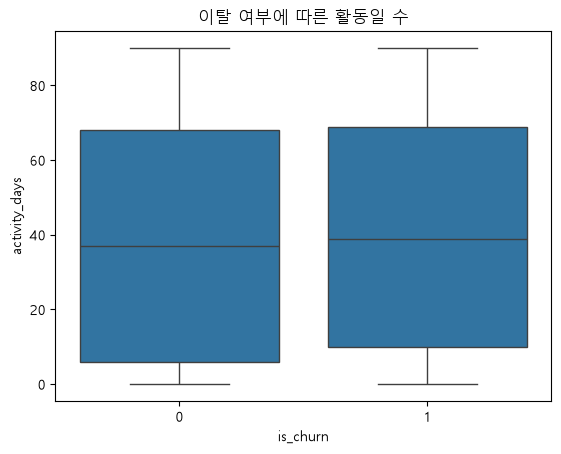

In [46]:
# 활동일 수 비교
sns.boxplot(data=train, x="is_churn", y="activity_days")
plt.title("이탈 여부에 따른 활동일 수")
plt.show()

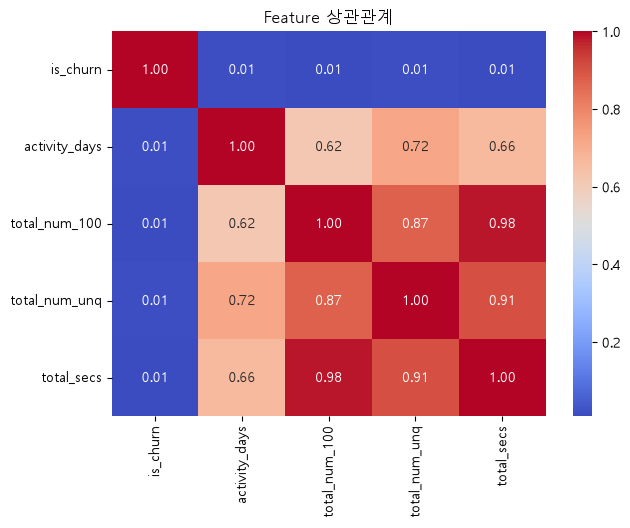

In [47]:
# 피처 상관관계
corr_cols = [
    "is_churn",
    "activity_days",
    "total_num_100",
    "total_num_unq",
    "total_secs"
]

plt.figure(figsize=(7, 5))

sns.heatmap(
    train[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature 상관관계")
plt.show()

# Feature Engineering

## user_logs Features

In [48]:
OBS_DAYS = 90

for frame in (train, valid):

    days = pd.to_numeric(
        frame["activity_days"], errors="coerce"
    )

    active_days = days.replace(0, np.nan)

    # H1. Activity Rate
    frame["activity_rate"] = days / OBS_DAYS

    # H2. Listening Time per Active Day
    frame["secs_per_active_day"] = (
        frame["total_secs"] / active_days
    )

    # H3. Completed Songs per Active Day
    frame["completed_per_active_day"] = (
        frame["total_num_100"] / active_days
    )

    # H4. Unique Songs per Active Day
    frame["unq_per_active_day"] = (
        frame["total_num_unq"] / active_days
    )

In [49]:
# Feature Comparison by Churn

feature_cols = [
    "activity_rate",
    "secs_per_active_day",
    "completed_per_active_day",
    "unq_per_active_day"
]

display(
    train.groupby(target)[feature_cols]
    .median()
    .T
)

is_churn,0,1
activity_rate,0.411111,0.433333
secs_per_active_day,4964.654232,5347.609040
completed_per_active_day,18.321634,19.641975
unq_per_active_day,20.333333,21.947368


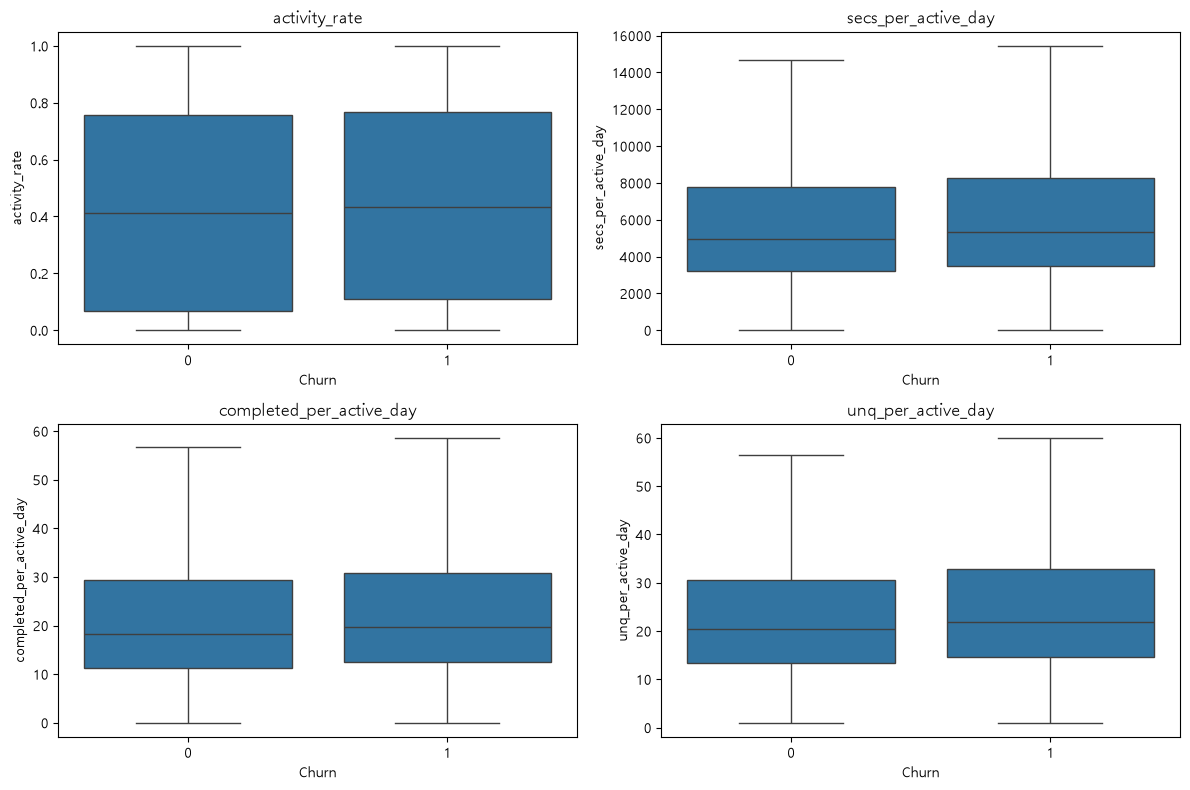

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, feature_cols):

    sns.boxplot(
        data=train,
        x=target,
        y=col,
        ax=ax,
        showfliers=False
    )

    ax.set_title(col)
    ax.set_xlabel("Churn")

plt.tight_layout()
plt.show()

In [51]:
display(
    train.groupby(target)["days_since_last_log"]
    .agg(["mean", "median", "max"])
)

,mean,median,max
is_churn,,,
0,4.408167,0.0,89.0
1,4.039948,0.0,89.0


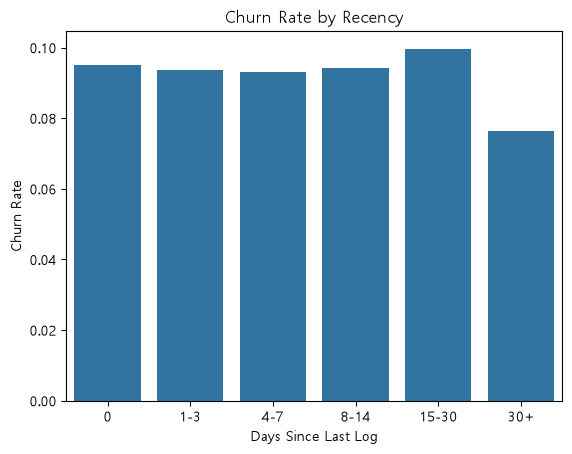

In [52]:
# Recency Groups
train["recency_group"] = pd.cut(
    train["days_since_last_log"],
    bins=[-1, 0, 3, 7, 14, 30, np.inf],
    labels=["0", "1-3", "4-7", "8-14", "15-30", "30+"]
)

recency_churn = (
    train.groupby("recency_group", observed=True)[target]
    .mean()
    .reset_index()
)

sns.barplot(data=recency_churn, x="recency_group", y=target)

plt.title("Churn Rate by Recency")
plt.xlabel("Days Since Last Log")
plt.ylabel("Churn Rate")
plt.show()

In [53]:
display(
    train.groupby("recency_group", observed=True)[target]
    .agg(
        customers="count",
        churn_rate="mean"
    )
)

,customers,churn_rate
recency_group,,
0,36141,0.094989
1-3,15297,0.093548
4-7,5463,0.092989
8-14,3109,0.094243
15-30,2578,0.099690
30+,2761,0.076422


## Additional Features

In [54]:
for frame in (train, valid):

    # H1. 최근 7일간 미이용 고객
    frame["inactive_7days"] = (
        frame["days_since_last_log"].gt(7) |
        frame["has_log"].eq(0)
    ).astype(int)

    # H2. 청취시간 1시간당 완청 곡 수
    listening_hours = frame["total_secs"].replace(0, np.nan) / 3600

    frame["completed_per_hour"] = (
        frame["total_num_100"] / listening_hours
    )

    # H3. 과거 거래 취소 비율
    tx_count = frame["transaction_count"].replace(0, np.nan)

    frame["cancel_rate"] = (
        frame["cancel_count"] / tx_count
    )

    # H4. 자동 갱신 미사용 + 낮은 활동량
    frame["no_auto_renew_low_activity"] = (
        frame["last_auto_renew"].eq(0) &
        frame["activity_days"].le(5)
    ).astype(int)

    # H5. 장기 가입 + 낮은 활동량
    registration = pd.to_datetime(
        frame["registration_init_time"].astype("Int64").astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

    frame["tenure_days"] = (
        pd.Timestamp("2017-02-28") - registration
    ).dt.days

    frame["long_tenure_low_activity"] = (
        frame["tenure_days"].ge(365) &
        frame["activity_days"].le(5)
    ).astype(int)

In [55]:
feature_cols = [
    "inactive_7days",
    "completed_per_hour",
    "cancel_rate",
    "no_auto_renew_low_activity",
    "long_tenure_low_activity"
]

display(
    train.groupby(target)[feature_cols]
    .mean()
    .T
    .round(4)
)

is_churn,0,1
inactive_7days,0.2926,0.2498
completed_per_hour,13.0219,13.0727
cancel_rate,0.0131,0.0228
no_auto_renew_low_activity,0.0021,0.0528
long_tenure_low_activity,0.0942,0.1128


In [56]:
binary_features = [
    "inactive_7days",
    "no_auto_renew_low_activity",
    "long_tenure_low_activity"
]

for col in binary_features:
    print(f"\n[{col}]")

    display(
        train.groupby(col)[target]
        .agg(
            customers="count",
            churn_rate="mean"
        )
        .round(4)
    )


[inactive_7days]


,customers,churn_rate
inactive_7days,,
0,56901,0.0944
1,23099,0.0774



[no_auto_renew_low_activity]


,customers,churn_rate
no_auto_renew_low_activity,,
0,79467,0.0854
1,533,0.7092



[long_tenure_low_activity]


,customers,churn_rate
long_tenure_low_activity,,
0,72333,0.0878
1,7667,0.1054


# Data Preprocessing

In [57]:
# 1. 로그 결측치 처리

for frame in (train, valid):

    frame["days_since_last_log"] = (
        frame["days_since_last_log"].fillna(90)
    )

    # 무한대 처리
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)

In [58]:
# 2. Features / Target Split

excluded = [
    "msno",
    "registration_init_time",
    "bd",
    "days_to_expire",  # 데이터 누수(정답 유출) → 제외
    "recency_group"  # EDA용 컬럼 제외
]

x_train = train.drop(
    columns=[target] + excluded,
    errors="ignore"
).copy()

x_valid = valid.drop(
    columns=[target] + excluded,
    errors="ignore"
).copy()

y_train = train[target].astype(int)
y_valid = valid[target].astype(int)

In [59]:
# 3. Feature Types

cat_cols = [
    "city",
    "gender",
    "registered_via"
]

cat_cols = [
    col for col in cat_cols
    if col in x_train.columns
]

num_cols = [
    col for col in x_train.columns
    if col not in cat_cols
]

assert "days_to_expire" not in num_cols, "누수 피처 days_to_expire가 포함되어 있음"

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['city', 'gender', 'registered_via']
Numerical: ['transaction_count', 'cancel_count', 'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days', 'cancel_on_last_date', 'activity_days', 'total_secs', 'total_num_100', 'total_num_unq', 'days_since_last_log', 'has_transaction', 'has_log', 'activity_rate', 'secs_per_active_day', 'completed_per_active_day', 'unq_per_active_day', 'inactive_7days', 'completed_per_hour', 'cancel_rate', 'no_auto_renew_low_activity', 'tenure_days', 'long_tenure_low_activity']


In [60]:
# 4. Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# 수치형
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median",
        keep_empty_features=True
    )),
    ("scaler", StandardScaler())
])

# 범주형
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="unknown"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# 데이터 타입 정리
for frame in (x_train, x_valid):

    for col in num_cols:
        frame[col] = pd.to_numeric(
            frame[col], errors="coerce"
        )

    for col in cat_cols:
        frame[col] = (
            frame[col]
            .astype("string")
            .fillna("unknown")
            .astype(str)
        )

# 통합 전처리
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# 학습 데이터 기준
x_train_ready = preprocess.fit_transform(x_train)

# 검증 데이터에는 transform만 적용
x_valid_ready = preprocess.transform(x_valid)

print("Train:", x_train_ready.shape)
print("Valid:", x_valid_ready.shape)

Train: (80000, 55)
Valid: (20000, 55)


In [61]:
# 5. Validation

print("Train NaN:", np.isnan(x_train_ready).sum())
print("Valid NaN:", np.isnan(x_valid_ready).sum())

print("Train Inf:", np.isinf(x_train_ready).sum())
print("Valid Inf:", np.isinf(x_valid_ready).sum())

print("Feature Count:", x_train_ready.shape[1])

Train NaN: 0
Valid NaN: 0
Train Inf: 0
Valid Inf: 0
Feature Count: 55


# Modeling

In [62]:
import copy
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

DROPOUT = 0.5   # Result 요약에 자동 반영됨

X = np.asarray(x_train_ready, dtype=np.float32)
X_valid = np.asarray(x_valid_ready, dtype=np.float32)
y = y_train.to_numpy(dtype=np.float32)

# EarlyStopping에 쓸 데이터는 train 안에서 분리
X_fit, X_stop, y_fit, y_stop = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

loader = DataLoader(
    TensorDataset(torch.from_numpy(X_fit), torch.from_numpy(y_fit)),
    batch_size=256,
    shuffle=True
)

X_stop_t = torch.from_numpy(X_stop).to(device)
y_stop_t = torch.from_numpy(y_stop).to(device)

# Dropout 추가
model = nn.Sequential(
    nn.Linear(X.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(DROPOUT),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(DROPOUT),
    nn.Linear(32, 1)
).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

best_loss = float("inf")
best_weights = None
best_epoch = 0
wait = 0
patience = 8

for epoch in range(100):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb).squeeze(1)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        stop_logits = model(X_stop_t).squeeze(1)
        stop_loss = loss_fn(stop_logits, y_stop_t).item()

    print(f"Epoch {epoch + 1:3d} | val_loss: {stop_loss:.4f}")

    if stop_loss < best_loss:
        best_loss = stop_loss
        best_weights = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("EarlyStopping")
            break

last_epoch = epoch + 1
model.load_state_dict(best_weights)

# 원래 valid 데이터로 최종 평가
model.eval()
with torch.no_grad():
    logits = model(torch.from_numpy(X_valid).to(device)).squeeze(1)
    proba = torch.sigmoid(logits).cpu().numpy()

pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_valid, proba), 4))
print("PR-AUC:", round(average_precision_score(y_valid, proba), 4))
print("F1@0.5:", round(f1_score(y_valid, pred), 4))

Epoch   1 | val_loss: 0.2164
Epoch   2 | val_loss: 0.2086
Epoch   3 | val_loss: 0.2075
Epoch   4 | val_loss: 0.2082
Epoch   5 | val_loss: 0.2073
Epoch   6 | val_loss: 0.2066
Epoch   7 | val_loss: 0.2065
Epoch   8 | val_loss: 0.2059
Epoch   9 | val_loss: 0.2056
Epoch  10 | val_loss: 0.2052
Epoch  11 | val_loss: 0.2056
Epoch  12 | val_loss: 0.2060
Epoch  13 | val_loss: 0.2046
Epoch  14 | val_loss: 0.2043
Epoch  15 | val_loss: 0.2041
Epoch  16 | val_loss: 0.2046
Epoch  17 | val_loss: 0.2039
Epoch  18 | val_loss: 0.2038
Epoch  19 | val_loss: 0.2035
Epoch  20 | val_loss: 0.2035
Epoch  21 | val_loss: 0.2035
Epoch  22 | val_loss: 0.2031
Epoch  23 | val_loss: 0.2030
Epoch  24 | val_loss: 0.2029
Epoch  25 | val_loss: 0.2028
Epoch  26 | val_loss: 0.2026
Epoch  27 | val_loss: 0.2027
Epoch  28 | val_loss: 0.2025
Epoch  29 | val_loss: 0.2026
Epoch  30 | val_loss: 0.2023
Epoch  31 | val_loss: 0.2023
Epoch  32 | val_loss: 0.2022
Epoch  33 | val_loss: 0.2023
Epoch  34 | val_loss: 0.2022
Epoch  35 | va

## ROC Curve

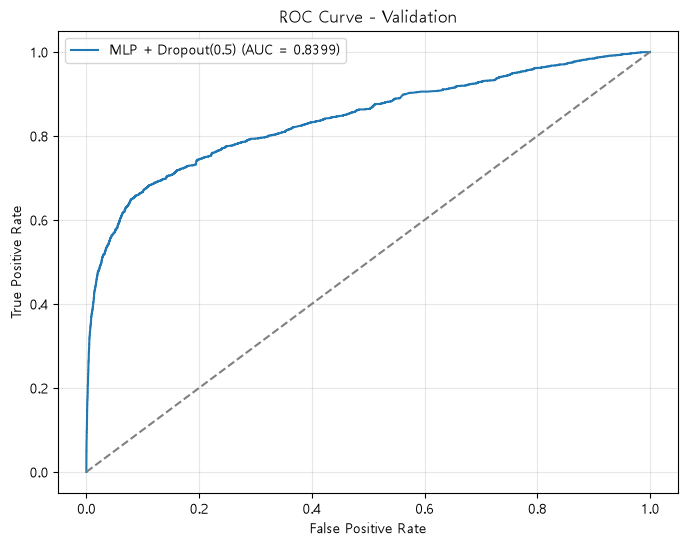

In [63]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_valid, proba)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr,
    label=f"MLP + Dropout({DROPOUT}) (AUC = {roc_auc_score(y_valid, proba):.4f})"
)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Result

In [64]:
# 학습·평가 결과 요약 (실행할 때마다 자동으로 갱신됨)
result = pd.Series({
    "Dropout": DROPOUT,
    "학습 종료 epoch": last_epoch,
    "최저 검증 손실 epoch": best_epoch,
    "최저 검증 손실": round(best_loss, 4),
    "ROC-AUC": round(roc_auc_score(y_valid, proba), 4),
    "PR-AUC": round(average_precision_score(y_valid, proba), 4),
    "F1-score (기준값 0.5)": round(f1_score(y_valid, pred), 4),
}, name="값")
display(result.to_frame())

,값
Dropout,0.5000
학습 종료 epoch,45.0000
최저 검증 손실 epoch,37.0000
최저 검증 손실,0.2017
ROC-AUC,0.8399
PR-AUC,0.5805
F1-score (기준값 0.5),0.5119
